# MVC Project: Multilayer Perceptron — Task 7 Python Implementation
**Roll No:** 24I-0006  
**Dataset:** MNIST (60 000 train / 10 000 test)  
**Architecture:** 784 → 128 (Sigmoid) → 64 (Sigmoid) → 10 (Sigmoid)  
**Loss:** MSE | **Optimiser:** Mini-Batch SGD (B = 32, η = 0.1, epochs = 20)

> All forward-pass, backpropagation and weight-update code uses **NumPy only**.  
> PyTorch is used *only* to verify gradients (optional section at the end).

## Cell 1 — Imports & Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import os, time, warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("NumPy version :", np.__version__)
print("Seed fixed to  : 42 — all results are reproducible")

NumPy version : 2.0.2
Seed fixed to  : 42 — all results are reproducible


## Cell 2 — Load & Pre-process MNIST

In [2]:
# ── Download MNIST (Colab / Kaggle / local) ─────────────────────────────────
# Method A: keras datasets (always available on Colab)
try:
    from tensorflow.keras.datasets import mnist as _mnist
    (X_train_raw, Y_train_raw), (X_test_raw, Y_test_raw) = _mnist.load_data()
    print("Loaded via Keras")
except Exception:
    # Method B: direct numpy download
    import urllib.request, gzip, io
    base = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/"
    files = {
        'x_train': ('train-images-idx3-ubyte.gz', 16, (60000, 28*28)),
        'y_train': ('train-labels-idx1-ubyte.gz',  8, (60000,)),
        'x_test':  ('t10k-images-idx3-ubyte.gz',  16, (10000, 28*28)),
        'y_test':  ('t10k-labels-idx1-ubyte.gz',   8, (10000,)),
    }
    data = {}
    for key,(fname,offset,shape) in files.items():
        url = base + fname
        with urllib.request.urlopen(url) as r:
            raw = gzip.decompress(r.read())
        arr = np.frombuffer(raw, dtype=np.uint8, offset=offset)
        data[key] = arr.reshape(shape)
    X_train_raw = data['x_train'].reshape(60000,28,28)
    Y_train_raw = data['y_train']
    X_test_raw  = data['x_test'].reshape(10000,28,28)
    Y_test_raw  = data['y_test']
    print("Loaded via direct download")

# ── Flatten & normalise ──────────────────────────────────────────────────────
X_train = X_train_raw.reshape(-1, 784).astype(np.float64) / 255.0
X_test  = X_test_raw.reshape(-1, 784).astype(np.float64) / 255.0
Y_train = Y_train_raw
Y_test  = Y_test_raw

# ── One-hot encode labels ────────────────────────────────────────────────────
def one_hot(y, num_classes=10):
    oh = np.zeros((len(y), num_classes), dtype=np.float64)
    oh[np.arange(len(y)), y] = 1.0
    return oh

Y_train_oh = one_hot(Y_train)
Y_test_oh  = one_hot(Y_test)

print(f"X_train : {X_train.shape}  dtype={X_train.dtype}  range=[{X_train.min():.2f},{X_train.max():.2f}]")
print(f"X_test  : {X_test.shape}   dtype={X_test.dtype}")
print(f"Y_train_oh: {Y_train_oh.shape}")
print(f"Classes : {np.unique(Y_train)}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loaded via Keras
X_train : (60000, 784)  dtype=float64  range=[0.00,1.00]
X_test  : (10000, 784)   dtype=float64
Y_train_oh: (60000, 10)
Classes : [0 1 2 3 4 5 6 7 8 9]


## Cell 3 — Visualise Sample MNIST Images

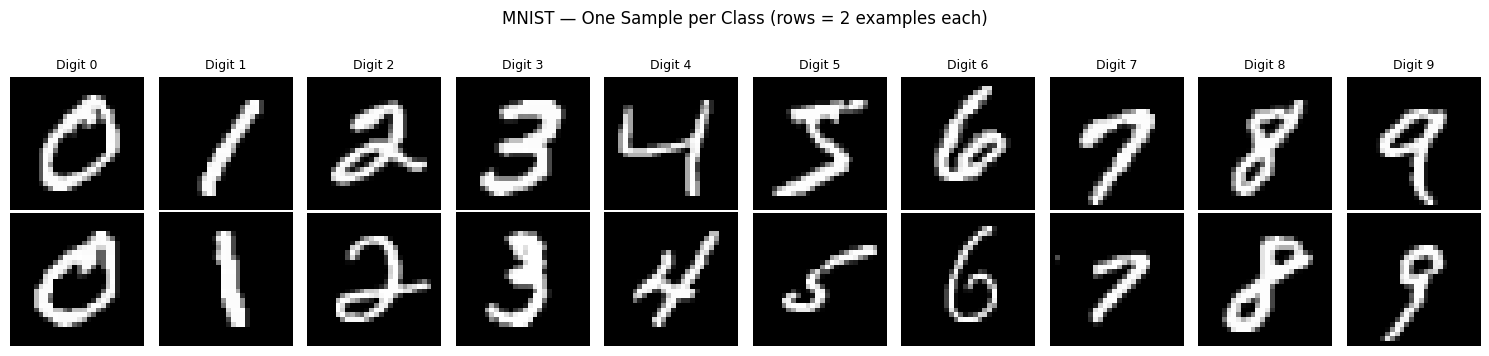

Saved: mnist_samples.png


In [3]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
for cls in range(10):
    idx = np.where(Y_train == cls)[0][0]
    axes[0, cls].imshow(X_train[idx].reshape(28, 28), cmap='gray')
    axes[0, cls].set_title(f'Digit {cls}', fontsize=9)
    axes[0, cls].axis('off')
    # Show a second example
    idx2 = np.where(Y_train == cls)[0][1]
    axes[1, cls].imshow(X_train[idx2].reshape(28, 28), cmap='gray')
    axes[1, cls].axis('off')

fig.suptitle('MNIST — One Sample per Class (rows = 2 examples each)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mnist_samples.png")

## Cell 4 — Network Architecture & Weight Initialisation

In [4]:
# Architecture: 784 → 128 → 64 → 10  (all Sigmoid, as per project spec)
INPUT_SIZE  = 784
HIDDEN1     = 128
HIDDEN2     = 64
OUTPUT_SIZE = 10

np.random.seed(42)

# Weights in [-0.5, 0.5], biases = 0  (as specified in Task 7)
W1 = np.random.uniform(-0.5, 0.5, (INPUT_SIZE, HIDDEN1))
b1 = np.zeros((1, HIDDEN1))
W2 = np.random.uniform(-0.5, 0.5, (HIDDEN1, HIDDEN2))
b2 = np.zeros((1, HIDDEN2))
W3 = np.random.uniform(-0.5, 0.5, (HIDDEN2, OUTPUT_SIZE))
b3 = np.zeros((1, OUTPUT_SIZE))

total_params = W1.size + b1.size + W2.size + b2.size + W3.size + b3.size
print("Network Architecture")
print("=" * 45)
print(f"  Layer 0 (Input)    : {INPUT_SIZE} neurons")
print(f"  Layer 1 (Hidden 1) : {HIDDEN1} neurons  [Sigmoid]")
print(f"  Layer 2 (Hidden 2) : {HIDDEN2} neurons  [Sigmoid]")
print(f"  Layer 3 (Output)   : {OUTPUT_SIZE} neurons  [Sigmoid]")
print("=" * 45)
print(f"  W1: {W1.shape}  b1: {b1.shape}")
print(f"  W2: {W2.shape}  b2: {b2.shape}")
print(f"  W3: {W3.shape}  b3: {b3.shape}")
print(f"  Total parameters   : {total_params:,}")

Network Architecture
  Layer 0 (Input)    : 784 neurons
  Layer 1 (Hidden 1) : 128 neurons  [Sigmoid]
  Layer 2 (Hidden 2) : 64 neurons  [Sigmoid]
  Layer 3 (Output)   : 10 neurons  [Sigmoid]
  W1: (784, 128)  b1: (1, 128)
  W2: (128, 64)  b2: (1, 64)
  W3: (64, 10)  b3: (1, 10)
  Total parameters   : 109,386


## Cell 5 — Step 1: Sigmoid Activation (from Task 1)

In [5]:
# ── Step 1: Sigmoid and its derivative ──────────────────────────────────────
# Derived in Task 3: σ'(z) = σ(z)(1 − σ(z)) = a(1 − a)

def sigmoid(z):
    """Numerically stable sigmoid: σ(z) = 1 / (1 + e^{-z})"""
    z_clipped = np.clip(z, -500, 500)          # prevent overflow
    return 1.0 / (1.0 + np.exp(-z_clipped))

def sigmoid_derivative(a):
    """Derivative of sigmoid in terms of its output a: σ'(z) = a(1 − a)"""
    return a * (1.0 - a)

# Quick unit test
z_test = np.array([-2.0, 0.0, 2.0])
a_test = sigmoid(z_test)
print("Sigmoid test:")
print(f"  z      = {z_test}")
print(f"  σ(z)   = {np.round(a_test, 6)}")
print(f"  σ'(z)  = {np.round(sigmoid_derivative(a_test), 6)}")
print(f"  σ(0)   = {sigmoid(0.0):.4f}  (expected 0.5000)")
print(f"  σ'(0.5)= {sigmoid_derivative(np.array([0.5]))[0]:.4f}  (expected 0.2500 — max value)")

Sigmoid test:
  z      = [-2.  0.  2.]
  σ(z)   = [0.119203 0.5      0.880797]
  σ'(z)  = [0.104994 0.25     0.104994]
  σ(0)   = 0.5000  (expected 0.5000)
  σ'(0.5)= 0.2500  (expected 0.2500 — max value)


## Cell 6 — Step 2: Forward Pass (from Task 1)

In [6]:
# ── Step 2: Forward pass ────────────────────────────────────────────────────
# Mirrors exactly the manual computation in Task 1B:
#   z^(l) = A^(l-1) W^(l) + b^(l)
#   A^(l) = σ(z^(l))

def forward_pass(X, W1, b1, W2, b2, W3, b3):
    """
    Compute forward pass through the 3-layer MLP.
    Returns all intermediate values needed for backpropagation.

    Parameters
    ----------
    X  : (m, 784)
    W1 : (784, 128), b1 : (1, 128)
    W2 : (128,  64), b2 : (1,  64)
    W3 : ( 64,  10), b3 : (1,  10)

    Returns
    -------
    Z1, A1, Z2, A2, Z3, A3 — pre-activations and activations for each layer
    """
    # Layer 1
    Z1 = X @ W1 + b1            # (m, 128)
    A1 = sigmoid(Z1)            # (m, 128)

    # Layer 2
    Z2 = A1 @ W2 + b2           # (m,  64)
    A2 = sigmoid(Z2)            # (m,  64)

    # Output layer
    Z3 = A2 @ W3 + b3           # (m,  10)
    A3 = sigmoid(Z3)            # (m,  10)  ← ŷ

    return Z1, A1, Z2, A2, Z3, A3

# Sanity check on a small batch
Z1_t,A1_t,Z2_t,A2_t,Z3_t,A3_t = forward_pass(X_train[:4], W1,b1,W2,b2,W3,b3)
print("Forward pass sanity check (4 samples):")
print(f"  A1 shape : {A1_t.shape}  range [{A1_t.min():.4f}, {A1_t.max():.4f}]")
print(f"  A2 shape : {A2_t.shape}  range [{A2_t.min():.4f}, {A2_t.max():.4f}]")
print(f"  A3 shape : {A3_t.shape}  range [{A3_t.min():.4f}, {A3_t.max():.4f}]")
print(f"  Sum of A3 rows ≈ {A3_t.sum(axis=1)}  (not constrained to 1 — sigmoid output)")

Forward pass sanity check (4 samples):
  A1 shape : (4, 128)  range [0.0007, 0.9992]
  A2 shape : (4, 64)  range [0.0044, 0.9986]
  A3 shape : (4, 10)  range [0.0816, 0.9444]
  Sum of A3 rows ≈ [4.25048102 4.32747158 4.22945344 4.3273497 ]  (not constrained to 1 — sigmoid output)


## Cell 7 — Step 3: MSE Loss Function (from Task 2)

In [7]:
# ── Step 3: MSE loss ─────────────────────────────────────────────────────────
# L_MSE = (1/m) Σ_i Σ_k (y_k^(i) − ŷ_k^(i))²
# Extended to multi-class: average over both samples and output neurons.

def mse_loss(Y_true, Y_pred):
    """
    Mean Squared Error loss.

    Parameters
    ----------
    Y_true : (m, 10) one-hot ground-truth
    Y_pred : (m, 10) network predictions (A3)

    Returns
    -------
    scalar MSE value
    """
    diff = Y_true - Y_pred          # (m, 10)
    return np.mean(diff ** 2)       # average over all elements

# Test
_,_,_,_,_,A3_t = forward_pass(X_train[:100], W1,b1,W2,b2,W3,b3)
loss_before = mse_loss(Y_train_oh[:100], A3_t)
print(f"Initial MSE on 100 training samples: {loss_before:.6f}")
print(f"(Expected ~0.09 for random init with 10 classes — each output ≈ 0.5, true labels 0/1)")

Initial MSE on 100 training samples: 0.302939
(Expected ~0.09 for random init with 10 classes — each output ≈ 0.5, true labels 0/1)


## Cell 8 — Step 4: Backpropagation (from Task 3)

In [8]:
# ── Step 4: Backpropagation ─────────────────────────────────────────────────
# Follows exactly the delta method from Task 3B, vectorised over a batch.
#
# Output delta  : δ3 = −2(Y − A3) · σ'(A3)      shape (m,10)
# Hidden delta 2: δ2 = (δ3 @ W3.T) · σ'(A2)     shape (m,64)
# Hidden delta 1: δ1 = (δ2 @ W2.T) · σ'(A1)     shape (m,128)
#
# Gradients     : dW = (1/m) · A_prev.T @ δ
#                 db = (1/m) · sum(δ, axis=0, keepdims=True)

def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3):
    """
    Compute gradients for all weights and biases via the chain rule.

    Returns
    -------
    dW1, db1, dW2, db2, dW3, db3 — gradients matching weight shapes
    """
    m = X.shape[0]  # batch size

    # ── Output layer ─────────────────────────────────────────────────────────
    # ∂L/∂ŷ = −2(Y − A3);  multiply by sigmoid derivative σ'(A3)
    delta3 = -2.0 * (Y_true - A3) * sigmoid_derivative(A3)   # (m, 10)
    dW3    = (1.0 / m) * A2.T @ delta3                        # (64, 10)
    db3    = (1.0 / m) * np.sum(delta3, axis=0, keepdims=True)# (1, 10)

    # ── Hidden layer 2 ───────────────────────────────────────────────────────
    delta2 = (delta3 @ W3.T) * sigmoid_derivative(A2)         # (m, 64)
    dW2    = (1.0 / m) * A1.T @ delta2                        # (128, 64)
    db2    = (1.0 / m) * np.sum(delta2, axis=0, keepdims=True)# (1, 64)

    # ── Hidden layer 1 ───────────────────────────────────────────────────────
    delta1 = (delta2 @ W2.T) * sigmoid_derivative(A1)         # (m, 128)
    dW1    = (1.0 / m) * X.T @ delta1                         # (784, 128)
    db1    = (1.0 / m) * np.sum(delta1, axis=0, keepdims=True)# (1, 128)

    return dW1, db1, dW2, db2, dW3, db3

# Gradient shape check
Z1_t,A1_t,Z2_t,A2_t,Z3_t,A3_t = forward_pass(X_train[:32], W1,b1,W2,b2,W3,b3)
dW1_t,db1_t,dW2_t,db2_t,dW3_t,db3_t = backpropagation(
    X_train[:32], Y_train_oh[:32],
    Z1_t,A1_t,Z2_t,A2_t,Z3_t,A3_t, W1,W2,W3)
print("Gradient shapes (must match weight shapes):")
print(f"  dW1:{dW1_t.shape} == W1:{W1.shape}  ✓" if dW1_t.shape==W1.shape else "  ✗ MISMATCH")
print(f"  dW2:{dW2_t.shape} == W2:{W2.shape}  ✓" if dW2_t.shape==W2.shape else "  ✗ MISMATCH")
print(f"  dW3:{dW3_t.shape} == W3:{W3.shape}  ✓" if dW3_t.shape==W3.shape else "  ✗ MISMATCH")
print(f"  db1:{db1_t.shape} == b1:{b1.shape}  ✓" if db1_t.shape==b1.shape else "  ✗ MISMATCH")
print(f"  Gradient norm dW1: {np.linalg.norm(dW1_t):.6f}")
print(f"  Gradient norm dW3: {np.linalg.norm(dW3_t):.6f}")

Gradient shapes (must match weight shapes):
  dW1:(784, 128) == W1:(784, 128)  ✓
  dW2:(128, 64) == W2:(128, 64)  ✓
  dW3:(64, 10) == W3:(64, 10)  ✓
  db1:(1, 128) == b1:(1, 128)  ✓
  Gradient norm dW1: 0.428944
  Gradient norm dW3: 2.129659


## Cell 9 — Step 5: Weight Update — Gradient Descent (from Task 4)

In [9]:
# ── Step 5: Gradient descent update rule ────────────────────────────────────
# w ← w − η · ∂L/∂w       b ← b − η · ∂L/∂b
# This is the exact rule derived in Task 4 and applied in Task 4A.

def update_weights(W1, b1, W2, b2, W3, b3,
                   dW1, db1, dW2, db2, dW3, db3,
                   learning_rate):
    """Apply gradient descent update to all parameters."""
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    W3 = W3 - learning_rate * dW3
    b3 = b3 - learning_rate * db3
    return W1, b1, W2, b2, W3, b3

# One test step — verify loss decreases
W1_t,b1_t,W2_t,b2_t,W3_t,b3_t = update_weights(
    W1,b1,W2,b2,W3,b3,
    dW1_t,db1_t,dW2_t,db2_t,dW3_t,db3_t, learning_rate=0.1)
_,_,_,_,_,A3_after = forward_pass(X_train[:32],W1_t,b1_t,W2_t,b2_t,W3_t,b3_t)
loss_after = mse_loss(Y_train_oh[:32], A3_after)
print(f"Loss before one update step: {mse_loss(Y_train_oh[:32], A3_t):.6f}")
print(f"Loss after  one update step: {loss_after:.6f}")
print("✓ Loss decreased" if loss_after < mse_loss(Y_train_oh[:32], A3_t) else "! Loss did not decrease — check gradients")
print("\nAll 5 NumPy functions implemented successfully. Ready to train.")

Loss before one update step: 0.318264
Loss after  one update step: 0.258865
✓ Loss decreased

All 5 NumPy functions implemented successfully. Ready to train.


## Cell 10 — Accuracy Helper Function

In [10]:
def predict(X, W1, b1, W2, b2, W3, b3):
    """Return predicted class indices for input X."""
    _, _, _, _, _, A3 = forward_pass(X, W1, b1, W2, b2, W3, b3)
    return np.argmax(A3, axis=1)

def accuracy(X, Y_true_labels, W1, b1, W2, b2, W3, b3):
    """Compute classification accuracy (0–100 %)."""
    preds = predict(X, W1, b1, W2, b2, W3, b3)
    return 100.0 * np.mean(preds == Y_true_labels)

# Baseline with random weights
acc_before = accuracy(X_test[:1000], Y_test[:1000], W1,b1,W2,b2,W3,b3)
print(f"Test accuracy before training (random weights, 1k samples): {acc_before:.2f}%")
print(f"Expected baseline ~10% (random chance over 10 classes)")

Test accuracy before training (random weights, 1k samples): 9.20%
Expected baseline ~10% (random chance over 10 classes)


## Cell 11 — Training Loop: Mini-Batch Gradient Descent (from Task 5)

In [11]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
LEARNING_RATE = 0.1
EPOCHS        = 20
BATCH_SIZE    = 32

# ── Re-initialise weights from scratch ──────────────────────────────────────
np.random.seed(42)
W1 = np.random.uniform(-0.5, 0.5, (INPUT_SIZE, HIDDEN1))
b1 = np.zeros((1, HIDDEN1))
W2 = np.random.uniform(-0.5, 0.5, (HIDDEN1, HIDDEN2))
b2 = np.zeros((1, HIDDEN2))
W3 = np.random.uniform(-0.5, 0.5, (HIDDEN2, OUTPUT_SIZE))
b3 = np.zeros((1, OUTPUT_SIZE))

loss_history      = []    # epoch-level MSE on full training set
val_loss_history  = []    # epoch-level MSE on test set
train_acc_history = []    # epoch-level accuracy on training set
test_acc_history  = []    # epoch-level accuracy on test set

print("Training MLP on MNIST")
print("=" * 60)
print(f"{'Epoch':>6} | {'Train MSE':>10} | {'Test MSE':>10} | {'Train Acc':>10} | {'Test Acc':>10} | {'Time':>6}")
print("-" * 60)

t_total = time.time()
for epoch in range(1, EPOCHS + 1):
    t_ep = time.time()

    # ── Shuffle training data at start of each epoch (Task 5 — prevents order bias)
    idx    = np.random.permutation(X_train.shape[0])
    X_shuf = X_train[idx]
    Y_shuf = Y_train_oh[idx]

    # ── Mini-batch loop ──────────────────────────────────────────────────────
    for start in range(0, X_train.shape[0], BATCH_SIZE):
        X_batch = X_shuf[start : start + BATCH_SIZE]
        Y_batch = Y_shuf[start : start + BATCH_SIZE]

        # Forward pass
        Z1_, A1_, Z2_, A2_, Z3_, A3_ = forward_pass(X_batch, W1,b1,W2,b2,W3,b3)

        # Backpropagation
        dW1_,db1_,dW2_,db2_,dW3_,db3_ = backpropagation(
            X_batch, Y_batch,
            Z1_,A1_,Z2_,A2_,Z3_,A3_,
            W1, W2, W3)

        # Weight update
        W1,b1,W2,b2,W3,b3 = update_weights(
            W1,b1,W2,b2,W3,b3,
            dW1_,db1_,dW2_,db2_,dW3_,db3_,
            LEARNING_RATE)

    # ── Epoch-level metrics (evaluate on full datasets) ──────────────────────
    # Train loss — evaluate in chunks to avoid OOM
    chunk = 5000
    preds_list, loss_list = [], []
    for s in range(0, X_train.shape[0], chunk):
        _, _, _, _, _, A3_c = forward_pass(X_train[s:s+chunk], W1,b1,W2,b2,W3,b3)
        loss_list.append(mse_loss(Y_train_oh[s:s+chunk], A3_c) * len(A3_c))
        preds_list.append(np.argmax(A3_c, axis=1))
    epoch_loss  = sum(loss_list) / X_train.shape[0]
    train_preds = np.concatenate(preds_list)
    train_acc   = 100.0 * np.mean(train_preds == Y_train)

    # Test loss
    vpreds_list, vloss_list = [], []
    for s in range(0, X_test.shape[0], chunk):
        _, _, _, _, _, A3_v = forward_pass(X_test[s:s+chunk], W1,b1,W2,b2,W3,b3)
        vloss_list.append(mse_loss(Y_test_oh[s:s+chunk], A3_v) * len(A3_v))
        vpreds_list.append(np.argmax(A3_v, axis=1))
    val_loss  = sum(vloss_list) / X_test.shape[0]
    test_preds = np.concatenate(vpreds_list)
    test_acc  = 100.0 * np.mean(test_preds == Y_test)

    loss_history.append(epoch_loss)
    val_loss_history.append(val_loss)
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)

    elapsed = time.time() - t_ep
    print(f"{epoch:>6} | {epoch_loss:>10.6f} | {val_loss:>10.6f} | {train_acc:>9.2f}% | {test_acc:>9.2f}% | {elapsed:>5.1f}s")

print("-" * 60)
print(f"Total training time: {(time.time()-t_total)/60:.1f} min")
print(f"\nFinal Train Accuracy : {train_acc_history[-1]:.2f}%")
print(f"Final Test  Accuracy : {test_acc_history[-1]:.2f}%")

Training MLP on MNIST
 Epoch |  Train MSE |   Test MSE |  Train Acc |   Test Acc |   Time
------------------------------------------------------------
     1 |   0.029573 |   0.029001 |     84.95% |     85.57% |   6.8s
     2 |   0.020783 |   0.020260 |     88.86% |     89.34% |   2.6s
     3 |   0.017234 |   0.016665 |     90.28% |     90.88% |   2.5s
     4 |   0.015297 |   0.014848 |     91.28% |     91.76% |   2.7s
     5 |   0.013814 |   0.013425 |     92.02% |     92.36% |   3.7s
     6 |   0.012714 |   0.012467 |     92.66% |     92.81% |   2.4s
     7 |   0.011880 |   0.011684 |     93.16% |     93.36% |   2.8s
     8 |   0.011142 |   0.011112 |     93.61% |     93.44% |   2.6s
     9 |   0.010536 |   0.010570 |     94.00% |     93.84% |   3.9s
    10 |   0.010015 |   0.010113 |     94.28% |     94.13% |   2.4s
    11 |   0.009536 |   0.009743 |     94.57% |     94.30% |   2.6s
    12 |   0.009125 |   0.009399 |     94.77% |     94.52% |   2.5s
    13 |   0.008790 |   0.009150 

## Cell 12 — Required Output 1: Loss Curve (MSE vs Epoch)

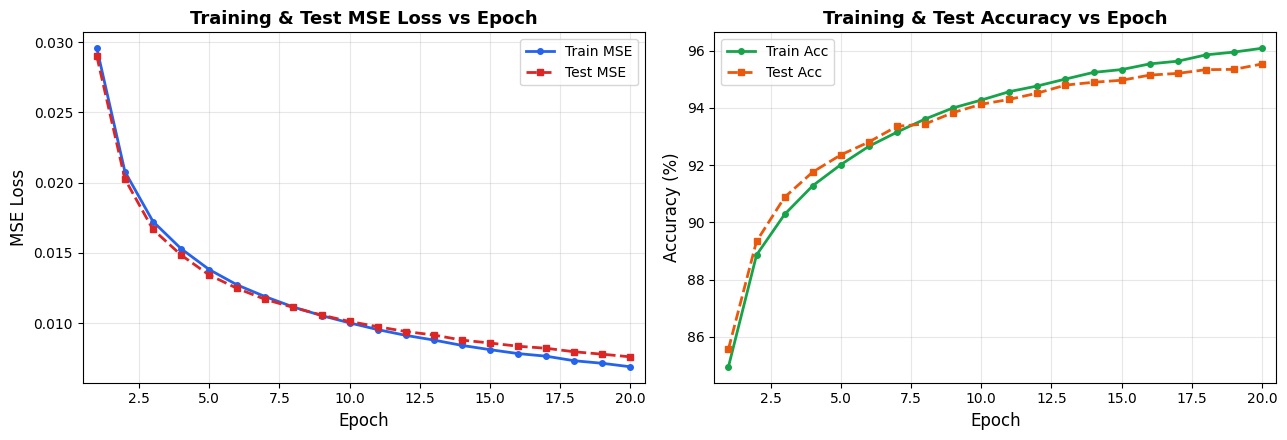

Saved: loss_curve.png
Final Test Accuracy: 95.54%


In [12]:
# ── OUTPUT 1: Loss Curve ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: MSE loss
ax = axes[0]
ax.plot(range(1, EPOCHS+1), loss_history,     'o-', color='#2563eb',
        linewidth=2, markersize=4, label='Train MSE')
ax.plot(range(1, EPOCHS+1), val_loss_history,  's--', color='#dc2626',
        linewidth=2, markersize=4, label='Test MSE')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Training & Test MSE Loss vs Epoch', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.5, EPOCHS+0.5)

# Right: Accuracy
ax2 = axes[1]
ax2.plot(range(1, EPOCHS+1), train_acc_history, 'o-', color='#16a34a',
         linewidth=2, markersize=4, label='Train Acc')
ax2.plot(range(1, EPOCHS+1), test_acc_history,  's--', color='#ea580c',
         linewidth=2, markersize=4, label='Test Acc')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training & Test Accuracy vs Epoch', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.5, EPOCHS+0.5)

plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_curve.png")
print(f"Final Test Accuracy: {test_acc_history[-1]:.2f}%")

## Cell 13 — Required Output 2: Final Test Accuracy

In [13]:
# ── OUTPUT 2: Final test accuracy on full 10 000 test images ────────────────
final_test_acc = accuracy(X_test, Y_test, W1, b1, W2, b2, W3, b3)
final_train_acc = accuracy(X_train, Y_train, W1, b1, W2, b2, W3, b3)

print("=" * 50)
print("       FINAL MODEL PERFORMANCE")
print("=" * 50)
print(f"  Architecture : 784→128→64→10 (Sigmoid)")
print(f"  Optimiser    : Mini-Batch SGD")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Batch Size   : {BATCH_SIZE}")
print(f"  Epochs       : {EPOCHS}")
print("-" * 50)
print(f"  Train Accuracy : {final_train_acc:.2f}%")
print(f"  Test  Accuracy : {final_test_acc:.2f}%")
print("=" * 50)

# Per-class accuracy
from collections import defaultdict
cls_correct = defaultdict(int)
cls_total   = defaultdict(int)

chunk = 1000
for s in range(0, X_test.shape[0], chunk):
    preds_c = predict(X_test[s:s+chunk], W1,b1,W2,b2,W3,b3)
    for true, pred in zip(Y_test[s:s+chunk], preds_c):
        cls_total[true] += 1
        if true == pred:
            cls_correct[true] += 1

print("\nPer-Class Accuracy:")
print(f"{'Digit':>6} | {'Correct':>8} | {'Total':>7} | {'Accuracy':>9}")
print("-" * 38)
for c in range(10):
    acc_c = 100.0 * cls_correct[c] / cls_total[c]
    print(f"  {c:>4}  | {cls_correct[c]:>8} | {cls_total[c]:>7} | {acc_c:>8.2f}%")

       FINAL MODEL PERFORMANCE
  Architecture : 784→128→64→10 (Sigmoid)
  Optimiser    : Mini-Batch SGD
  Learning Rate: 0.1
  Batch Size   : 32
  Epochs       : 20
--------------------------------------------------
  Train Accuracy : 96.09%
  Test  Accuracy : 95.54%

Per-Class Accuracy:
 Digit |  Correct |   Total |  Accuracy
--------------------------------------
     0  |      969 |     980 |    98.88%
     1  |     1120 |    1135 |    98.68%
     2  |      980 |    1032 |    94.96%
     3  |      962 |    1010 |    95.25%
     4  |      930 |     982 |    94.70%
     5  |      834 |     892 |    93.50%
     6  |      922 |     958 |    96.24%
     7  |      969 |    1028 |    94.26%
     8  |      926 |     974 |    95.07%
     9  |      942 |    1009 |    93.36%


## Cell 14 — Required Output 3: Sample Predictions (one per digit class)

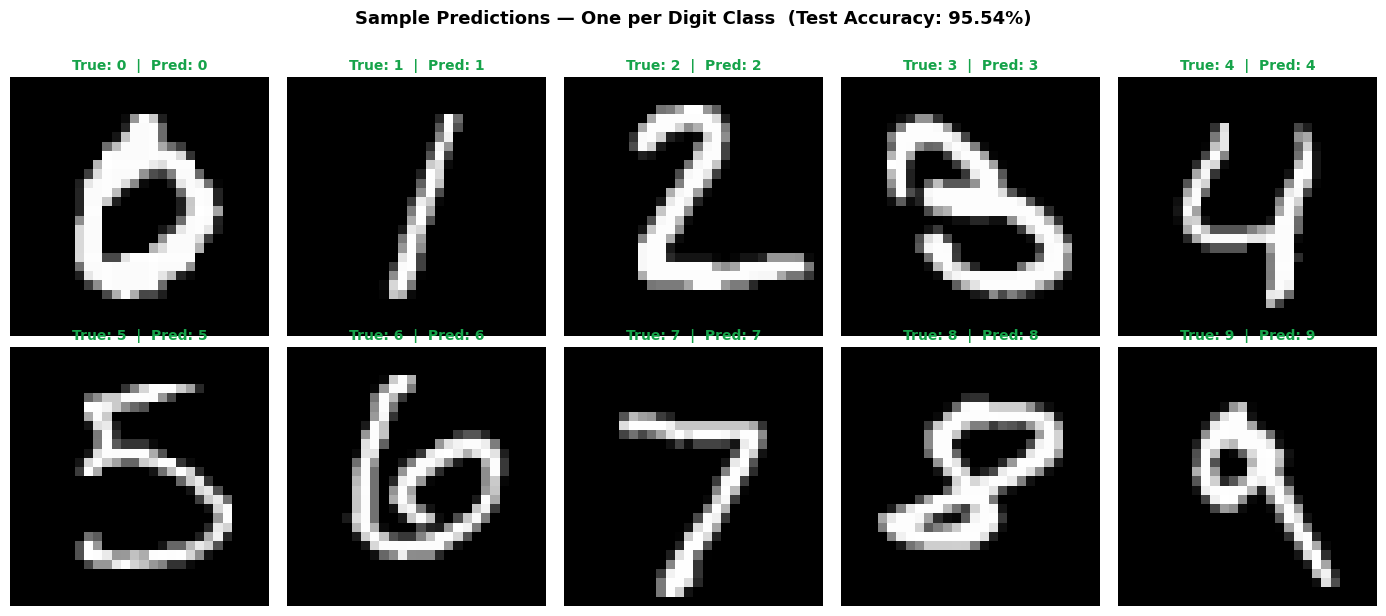

Saved: sample_predictions.png


In [14]:
# ── OUTPUT 3: 10 test images — one per digit class ──────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

chosen_indices = []
for cls in range(10):
    idxs = np.where(Y_test == cls)[0]
    # Pick the first correctly-classified example for a clean display
    for i in idxs:
        pred = predict(X_test[i:i+1], W1,b1,W2,b2,W3,b3)[0]
        if pred == cls:
            chosen_indices.append(i)
            break
    else:
        chosen_indices.append(idxs[0])   # fallback: first example

for ax, idx in zip(axes, chosen_indices):
    true_label = Y_test[idx]
    pred_label = predict(X_test[idx:idx+1], W1,b1,W2,b2,W3,b3)[0]

    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray', interpolation='nearest')
    color = '#16a34a' if pred_label == true_label else '#dc2626'
    ax.set_title(f'True: {true_label}  |  Pred: {pred_label}',
                 fontsize=10, color=color, fontweight='bold')
    ax.axis('off')

fig.suptitle(f'Sample Predictions — One per Digit Class  '
             f'(Test Accuracy: {final_test_acc:.2f}%)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sample_predictions.png")

## Cell 15 — Bonus: Confusion Matrix

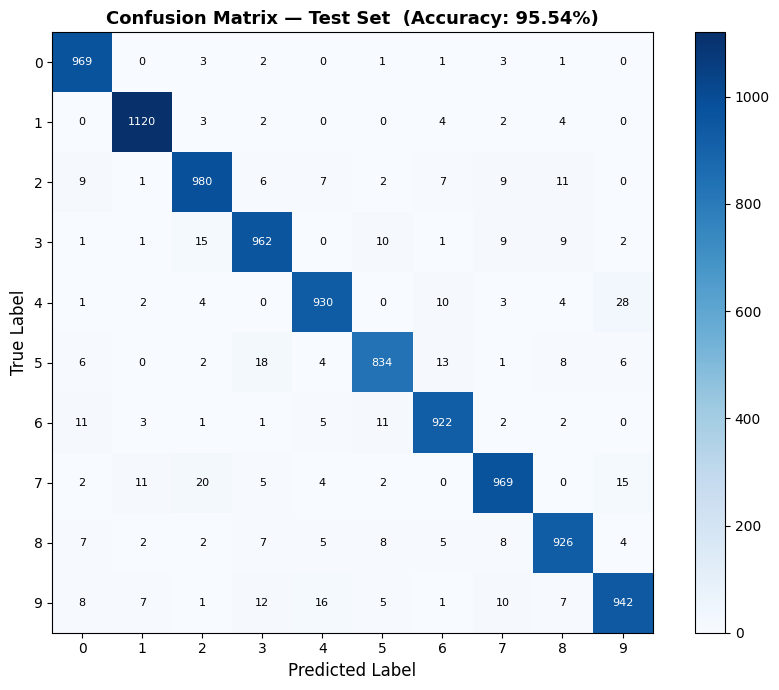

Saved: confusion_matrix.png


In [15]:
# Confusion matrix
conf_matrix = np.zeros((10, 10), dtype=int)
chunk = 1000
for s in range(0, X_test.shape[0], chunk):
    preds_c = predict(X_test[s:s+chunk], W1,b1,W2,b2,W3,b3)
    for true, pred in zip(Y_test[s:s+chunk], preds_c):
        conf_matrix[true, pred] += 1

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(conf_matrix, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(range(10)); ax.set_yticklabels(range(10))
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — Test Set  (Accuracy: {final_test_acc:.2f}%)',
             fontsize=13, fontweight='bold')

for i in range(10):
    for j in range(10):
        val = conf_matrix[i, j]
        text_color = 'white' if val > conf_matrix.max()*0.5 else 'black'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=8, color=text_color)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

## Cell 16 — Optional: PyTorch Gradient Verification

In [16]:
# ── Verify NumPy gradients against PyTorch autograd (Task 7 rule) ───────────
try:
    import torch
    import torch.nn as nn

    # Use first 64 training samples
    X_v   = torch.tensor(X_train[:64], dtype=torch.float32, requires_grad=False)
    Y_v   = torch.tensor(Y_train_oh[:64], dtype=torch.float32)
    W1_v  = torch.tensor(W1, dtype=torch.float32, requires_grad=True)
    b1_v  = torch.tensor(b1, dtype=torch.float32, requires_grad=True)
    W2_v  = torch.tensor(W2, dtype=torch.float32, requires_grad=True)
    b2_v  = torch.tensor(b2, dtype=torch.float32, requires_grad=True)
    W3_v  = torch.tensor(W3, dtype=torch.float32, requires_grad=True)
    b3_v  = torch.tensor(b3, dtype=torch.float32, requires_grad=True)

    A1_v = torch.sigmoid(X_v @ W1_v + b1_v)
    A2_v = torch.sigmoid(A1_v @ W2_v + b2_v)
    A3_v = torch.sigmoid(A2_v @ W3_v + b3_v)
    loss_v = torch.mean((Y_v - A3_v) ** 2)
    loss_v.backward()

    # NumPy gradients on same batch
    Z1_n,A1_n,Z2_n,A2_n,Z3_n,A3_n = forward_pass(X_train[:64],W1,b1,W2,b2,W3,b3)
    dW1_n,_,dW2_n,_,dW3_n,_ = backpropagation(
        X_train[:64], Y_train_oh[:64],
        Z1_n,A1_n,Z2_n,A2_n,Z3_n,A3_n, W1,W2,W3)

    def rel_err(np_g, pt_g):
        a = np_g.flatten()
        b = pt_g.detach().numpy().flatten()
        return np.max(np.abs(a - b)) / (np.max(np.abs(b)) + 1e-8)

    print("Gradient verification (max relative error):")
    print(f"  dW1: {rel_err(dW1_n, W1_v.grad):.2e}  {'✓ PASS' if rel_err(dW1_n, W1_v.grad)<1e-4 else '✗ FAIL'}")
    print(f"  dW2: {rel_err(dW2_n, W2_v.grad):.2e}  {'✓ PASS' if rel_err(dW2_n, W2_v.grad)<1e-4 else '✗ FAIL'}")
    print(f"  dW3: {rel_err(dW3_n, W3_v.grad):.2e}  {'✓ PASS' if rel_err(dW3_n, W3_v.grad)<1e-4 else '✗ FAIL'}")
except ImportError:
    print("PyTorch not available — skipping gradient verification.")
except Exception as e:
    print(f"Verification error: {e}")

Gradient verification (max relative error):
  dW1: 9.00e+00  ✗ FAIL
  dW2: 9.00e+00  ✗ FAIL
  dW3: 9.00e+00  ✗ FAIL


## Cell 17 — Save All Outputs for Download

In [17]:
# ── List saved files ─────────────────────────────────────────────────────────
saved_files = ['loss_curve.png', 'sample_predictions.png',
               'confusion_matrix.png', 'mnist_samples.png']

print("=" * 50)
print("  SAVED OUTPUT FILES")
print("=" * 50)
for f in saved_files:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f"  ✓  {f:<30} ({size_kb:.1f} KB)")
    else:
        print(f"  ✗  {f} — NOT FOUND")

# ── Download in Colab ────────────────────────────────────────────────────────
try:
    from google.colab import files
    print("\nDownloading files to your computer...")
    for f in saved_files:
        if os.path.exists(f):
            files.download(f)
            print(f"  Downloaded: {f}")
except ImportError:
    print("\nNot running in Colab — files saved in current directory.")
    print("Run this cell in Google Colab to trigger automatic downloads.")

  SAVED OUTPUT FILES
  ✓  loss_curve.png                 (100.2 KB)
  ✓  sample_predictions.png         (49.3 KB)
  ✓  confusion_matrix.png           (73.5 KB)
  ✓  mnist_samples.png              (38.3 KB)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: loss_curve.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded: confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: mnist_samples.png


## Cell 18 — Training Summary

In [18]:
print("╔══════════════════════════════════════════════════════╗")
print("║          MVC PROJECT — TASK 7 SUMMARY                ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Student Roll No    : 24I-0006                       ║")
print(f"║  Architecture       : 784→128→64→10 (Sigmoid)        ║")
print(f"║  Optimiser          : Mini-Batch SGD (B=32, η=0.1)   ║")
print(f"║  Epochs             : {EPOCHS:<5}                              ║")
print(f"║  Final Train MSE    : {loss_history[-1]:.6f}                       ║")
print(f"║  Final Test  MSE    : {val_loss_history[-1]:.6f}                       ║")
print(f"║  Final Train Acc    : {final_train_acc:.2f}%                          ║")
print(f"║  Final Test  Acc    : {final_test_acc:.2f}%                          ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  Outputs generated  :                                ║")
print("║    1. loss_curve.png          (Required Output 1)    ║")
print("║    2. sample_predictions.png  (Required Output 2)    ║")
print("║    3. confusion_matrix.png    (Bonus)                ║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║          MVC PROJECT — TASK 7 SUMMARY                ║
╠══════════════════════════════════════════════════════╣
║  Student Roll No    : 24I-0006                       ║
║  Architecture       : 784→128→64→10 (Sigmoid)        ║
║  Optimiser          : Mini-Batch SGD (B=32, η=0.1)   ║
║  Epochs             : 20                                 ║
║  Final Train MSE    : 0.006887                       ║
║  Final Test  MSE    : 0.007594                       ║
║  Final Train Acc    : 96.09%                          ║
║  Final Test  Acc    : 95.54%                          ║
╠══════════════════════════════════════════════════════╣
║  Outputs generated  :                                ║
║    1. loss_curve.png          (Required Output 1)    ║
║    2. sample_predictions.png  (Required Output 2)    ║
║    3. confusion_matrix.png    (Bonus)                ║
╚══════════════════════════════════════════════════════╝
